In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

In [2]:
DATA_DIR = 'data'

In [3]:
users = pd.read_csv('{}/users.csv.gz'.format(DATA_DIR))
events = pd.read_csv('{}/events.csv.gz'.format(DATA_DIR))
transactions = pd.read_csv('{}/transactions.csv.gz'.format(DATA_DIR))

## Preprocessing the data

### Clean user profile fields

In [4]:
# RAW
users.head()

,user_id,gender,canton,class_level,study,class_id
0,387604,NaN,NaN,NaN,False,NaN
1,387605,NaN,NaN,NaN,False,NaN
2,387608,NaN,NaN,NaN,True,9Q2M7
3,387613,NaN,NaN,NaN,False,NaN
4,387615,MALE,SG,Gymnasium - 3. Jahr,False,NaN


In [5]:
users_clean = users.copy()  # Work on a copy to keep raw data unchanged

# Normalize gender values and fill missing entries
users_clean['gender'] = (
    users_clean['gender']
    .replace({'*': np.nan, 'STAR': 'Other'})
    .fillna('Unknown')
)

# Fill missing categorical profile fields
users_clean['canton'] = users_clean['canton'].fillna('Unknown')
users_clean['class_level'] = users_clean['class_level'].fillna('Unknown')
users_clean['class_id'] = users_clean['class_id'].fillna('Unknown')

# Ensure study is boolean
users_clean['study'] = users_clean['study'].replace({'True': True, 'False': False}).fillna(False).astype(bool)

users_clean.head()

,user_id,gender,canton,class_level,study,class_id
0,387604,Unknown,Unknown,Unknown,False,Unknown
1,387605,Unknown,Unknown,Unknown,False,Unknown
2,387608,Unknown,Unknown,Unknown,True,9Q2M7
3,387613,Unknown,Unknown,Unknown,False,Unknown
4,387615,MALE,SG,Gymnasium - 3. Jahr,False,Unknown


In [6]:
del users
gc.collect()

1503

### Clean event timestamps and calendar features

In [7]:
# RAW
events.head()

,event_id,user_id,event_date,category,action,event_type,transaction_token,tracking_data,session_id,topic_id,session_closed,session_type,session_accepted
0,62,393211,2021-05-21 07:56:54.885,TASK,VIEW_QUESTION,VIEW,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN
1,63,393211,2021-05-21 07:58:18.912,TASK,SUBMIT_ANSWER,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN
2,64,393211,2021-05-21 07:58:27.207,TASK,NEXT,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN
3,65,393211,2021-05-21 07:58:27.589,TASK,VIEW_QUESTION,VIEW,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,NaN,NaN,NaN
4,66,393211,2021-05-21 08:03:42.588,TASK,SUBMIT_ANSWER,CLICK,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
events_clean = events.copy()  # Keep raw events unchanged

events_clean['event_date'] = pd.to_datetime(events_clean['event_date'], errors='coerce')
events_clean = events_clean.dropna(subset=['user_id', 'event_date'])  # Remove unusable rows

# Time-based features for analysis/aggregation
events_clean['date'] = events_clean['event_date'].dt.date
events_clean['year'] = events_clean['event_date'].dt.year
events_clean['month'] = events_clean['event_date'].dt.month
events_clean['dayofweek'] = events_clean['event_date'].dt.dayofweek
events_clean['hour'] = events_clean['event_date'].dt.hour
events_clean['week'] = events_clean['event_date'].dt.to_period('W').astype(str)

events_clean.head()

,event_id,user_id,event_date,category,action,event_type,transaction_token,tracking_data,session_id,topic_id,session_closed,session_type,session_accepted,date,year,month,dayofweek,hour,week
0,62,393211,2021-05-21 07:56:54.885,TASK,VIEW_QUESTION,VIEW,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
1,63,393211,2021-05-21 07:58:18.912,TASK,SUBMIT_ANSWER,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
2,64,393211,2021-05-21 07:58:27.207,TASK,NEXT,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
3,65,393211,2021-05-21 07:58:27.589,TASK,VIEW_QUESTION,VIEW,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
4,66,393211,2021-05-21 08:03:42.588,TASK,SUBMIT_ANSWER,CLICK,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23


In [9]:
del events
gc.collect()

0

### Clean transaction timestamps and scoring features

In [10]:
# RAW
transactions.head()

,transaction_id,transaction_token,user_id,document_id,document_version,evaluation,input,start_time,commit_time,user_agent,...,type,session_id,topic_id,session_closed,session_type,session_accepted,challenge,challenge_id,challenge_order,challenge_name
0,688413,88fdcaad-f73b-46a2-b561-d262f2441442,393211,awd0i1DlVtg6kuMZSkpmHa,75002,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 07:58:27.312000000,2021-05-21 08:03:43.020000000,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,MULTI_COLOR_HIGHLIGHT,NaN,NaN,NaN,NaN,NaN,True,1083.0,2.0,G3h – Training Rhetorik
1,688414,a75eb7b4-b2c2-47d4-9200-27980c175037,393211,arhWF3BT53V9W8cGOaZVPX,75012,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 08:04:05.067000000,2021-05-21 08:07:21.288999936,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,MULTI_COLOR_HIGHLIGHT,NaN,NaN,NaN,NaN,NaN,True,1083.0,3.0,G3h – Training Rhetorik
2,688415,61eb829d-bdda-4107-86af-ad9a14a7bdc9,393211,9wk5dtV2mF59odW0wCEYYc,75003,PARTIAL,"{""type"": ""CLOZE_TEXT"", ""clozeInputs"": [""Person...",2021-05-21 08:07:37.048000000,2021-05-21 08:13:30.953999872,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,CLOZE_TEXT,NaN,NaN,NaN,NaN,NaN,True,1083.0,4.0,G3h – Training Rhetorik
3,688416,30ff0d8a-865d-460b-9177-b698a52b0d5c,393211,afilxZ8LycP5LReULeKngW,75009,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Ich gehe i...",2021-05-21 08:13:38.943000000,2021-05-21 08:22:13.975000064,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,DND_PAIRS,NaN,NaN,NaN,NaN,NaN,True,1083.0,5.0,G3h – Training Rhetorik
4,688417,0adedf3b-ba35-4497-8c6b-b5c2f6fcbbf3,393211,76m6v05NCeX8x2Wr5tKRE3,75007,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Kleiner Ma...",2021-05-21 08:22:19.391000000,2021-05-21 08:22:55.366000128,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,DND_PAIRS,NaN,NaN,NaN,NaN,NaN,True,1083.0,6.0,G3h – Training Rhetorik


In [11]:
transactions_clean = transactions.copy()  # keep raw transactions unchanged

# parse timestamps and drop rows missing required keys/time
transactions_clean['start_time'] = pd.to_datetime(transactions_clean['start_time'], errors='coerce')
transactions_clean['commit_time'] = pd.to_datetime(transactions_clean['commit_time'], errors='coerce')
transactions_clean = transactions_clean.dropna(subset=['user_id', 'start_time'])

# derive time features from start_time
transactions_clean['date'] = transactions_clean['start_time'].dt.date
transactions_clean['year'] = transactions_clean['start_time'].dt.year
transactions_clean['month'] = transactions_clean['start_time'].dt.month
transactions_clean['dayofweek'] = transactions_clean['start_time'].dt.dayofweek
transactions_clean['hour'] = transactions_clean['start_time'].dt.hour
transactions_clean['week'] = transactions_clean['start_time'].dt.to_period('W').astype(str)

transactions_clean.head()

,transaction_id,transaction_token,user_id,document_id,document_version,evaluation,input,start_time,commit_time,user_agent,...,challenge,challenge_id,challenge_order,challenge_name,date,year,month,dayofweek,hour,week
0,688413,88fdcaad-f73b-46a2-b561-d262f2441442,393211,awd0i1DlVtg6kuMZSkpmHa,75002,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 07:58:27.312,2021-05-21 08:03:43.020000000,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,2.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23
1,688414,a75eb7b4-b2c2-47d4-9200-27980c175037,393211,arhWF3BT53V9W8cGOaZVPX,75012,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 08:04:05.067,2021-05-21 08:07:21.288999936,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,3.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23
2,688415,61eb829d-bdda-4107-86af-ad9a14a7bdc9,393211,9wk5dtV2mF59odW0wCEYYc,75003,PARTIAL,"{""type"": ""CLOZE_TEXT"", ""clozeInputs"": [""Person...",2021-05-21 08:07:37.048,2021-05-21 08:13:30.953999872,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,4.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23
3,688416,30ff0d8a-865d-460b-9177-b698a52b0d5c,393211,afilxZ8LycP5LReULeKngW,75009,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Ich gehe i...",2021-05-21 08:13:38.943,2021-05-21 08:22:13.975000064,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,5.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23
4,688417,0adedf3b-ba35-4497-8c6b-b5c2f6fcbbf3,393211,76m6v05NCeX8x2Wr5tKRE3,75007,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Kleiner Ma...",2021-05-21 08:22:19.391,2021-05-21 08:22:55.366000128,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,True,1083.0,6.0,G3h – Training Rhetorik,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23


In [12]:
del transactions
gc.collect()

0

In [13]:
# Clean evaluation labels and derive outcome flags
transactions_clean['evaluation'] = transactions_clean['evaluation'].fillna('UNKNOWN')

# Soft correctness score
transactions_clean['evaluation_score'] = transactions_clean['evaluation'].map({
    'CORRECT': 1.0,
    'PARTIAL': 0.5,
    'WRONG': 0.0,
    'UNKNOWN': 0.0
}).fillna(0.0)

transactions_clean['is_correct'] = (transactions_clean['evaluation'] == 'CORRECT').astype(int)
transactions_clean['is_partial'] = (transactions_clean['evaluation'] == 'PARTIAL').astype(int)
transactions_clean['is_unknown_eval'] = (transactions_clean['evaluation'] == 'UNKNOWN').astype(int)

# Compute response time in seconds
transactions_clean['response_time_sec'] = (
    transactions_clean['commit_time'] - transactions_clean['start_time']
).dt.total_seconds()

# Remove implausible response times (discard values > 1 hour but could be adjusted)
transactions_clean.loc[
    (transactions_clean['response_time_sec'] < 0) | (transactions_clean['response_time_sec'] > 3600),
    'response_time_sec'
] = np.nan

transactions_clean.head()

,transaction_id,transaction_token,user_id,document_id,document_version,evaluation,input,start_time,commit_time,user_agent,...,year,month,dayofweek,hour,week,evaluation_score,is_correct,is_partial,is_unknown_eval,response_time_sec
0,688413,88fdcaad-f73b-46a2-b561-d262f2441442,393211,awd0i1DlVtg6kuMZSkpmHa,75002,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 07:58:27.312,2021-05-21 08:03:43.020000000,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,7,2021-05-17/2021-05-23,0.5,0,1,0,315.708
1,688414,a75eb7b4-b2c2-47d4-9200-27980c175037,393211,arhWF3BT53V9W8cGOaZVPX,75012,PARTIAL,"{""type"": ""MULTI_COLOR_HIGHLIGHT"", ""highlighted...",2021-05-21 08:04:05.067,2021-05-21 08:07:21.288999936,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,8,2021-05-17/2021-05-23,0.5,0,1,0,196.222
2,688415,61eb829d-bdda-4107-86af-ad9a14a7bdc9,393211,9wk5dtV2mF59odW0wCEYYc,75003,PARTIAL,"{""type"": ""CLOZE_TEXT"", ""clozeInputs"": [""Person...",2021-05-21 08:07:37.048,2021-05-21 08:13:30.953999872,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,8,2021-05-17/2021-05-23,0.5,0,1,0,353.906
3,688416,30ff0d8a-865d-460b-9177-b698a52b0d5c,393211,afilxZ8LycP5LReULeKngW,75009,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Ich gehe i...",2021-05-21 08:13:38.943,2021-05-21 08:22:13.975000064,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,8,2021-05-17/2021-05-23,1.0,1,0,0,515.032
4,688417,0adedf3b-ba35-4497-8c6b-b5c2f6fcbbf3,393211,76m6v05NCeX8x2Wr5tKRE3,75007,CORRECT,"{""type"": ""DND_PAIRS"", ""input"": [""<p>Kleiner Ma...",2021-05-21 08:22:19.391,2021-05-21 08:22:55.366000128,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_6...,...,2021,5,4,8,2021-05-17/2021-05-23,1.0,1,0,0,35.975


### Build a user-relative timeline

In [14]:
# Define week 0 as each user's first recorded transaction
first_activity = (
    transactions_clean.groupby('user_id', as_index=False)['start_time']
    .min()
    .rename(columns={'start_time': 'first_activity_time'})
)

events_clean = events_clean.merge(first_activity, on='user_id', how='left')
transactions_clean = transactions_clean.merge(first_activity, on='user_id', how='left')

events_clean['relative_week'] = (
    (events_clean['event_date'] - events_clean['first_activity_time']).dt.days // 7
).astype('Int64')
transactions_clean['relative_week'] = (
    (transactions_clean['start_time'] - transactions_clean['first_activity_time']).dt.days // 7
).astype('Int64')

events_clean.head()



,event_id,user_id,event_date,category,action,event_type,transaction_token,tracking_data,session_id,topic_id,...,session_type,session_accepted,date,year,month,dayofweek,hour,week,first_activity_time,relative_week
0,62,393211,2021-05-21 07:56:54.885,TASK,VIEW_QUESTION,VIEW,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,-1
1,63,393211,2021-05-21 07:58:18.912,TASK,SUBMIT_ANSWER,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,-1
2,64,393211,2021-05-21 07:58:27.207,TASK,NEXT,CLICK,7a10ca52-ffb5-4069-8800-0dc86d778e94,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,-1
3,65,393211,2021-05-21 07:58:27.589,TASK,VIEW_QUESTION,VIEW,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,7,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,0
4,66,393211,2021-05-21 08:03:42.588,TASK,SUBMIT_ANSWER,CLICK,88fdcaad-f73b-46a2-b561-d262f2441442,NaN,NaN,NaN,...,NaN,NaN,2021-05-21,2021,5,4,8,2021-05-17/2021-05-23,2021-05-21 07:58:27.312,0


Negative relative_week values occur when a user has events recorded before their first transaction, since week 0 is defined from the first transaction timestamp.


*events is broader than transactions, so it can contain earlier activity like page views or navigation*

## Generic Features

In [15]:
# Aggregate per-user event activity features
event_user_features = events_clean.groupby('user_id').agg(
    n_events=('event_id', 'count'),
    n_active_days=('date', 'nunique'),
    n_active_weeks=('week', 'nunique'),
    first_event=('event_date', 'min'),
    last_event=('event_date', 'max'),
    mean_event_hour=('hour', 'mean')
).reset_index()

event_user_features.head()

,user_id,n_events,n_active_days,n_active_weeks,first_event,last_event,mean_event_hour
0,387604,5087,100,54,2021-05-22 05:12:11.416,2023-01-25 20:53:32.597,10.359741
1,387605,3604,54,33,2021-05-27 06:46:53.301,2022-11-01 08:22:13.245,10.089345
2,387608,2359,87,47,2021-09-05 08:29:42.198,2023-01-27 08:50:57.481,11.119118
3,387613,213,5,4,2021-07-28 07:55:26.135,2022-11-13 10:44:02.194,9.516432
4,387615,535,12,9,2021-08-28 13:14:30.684,2023-02-02 14:07:09.779,10.542056


In [16]:
# Count how many times each action appears per user
action_counts = pd.crosstab(events_clean['user_id'], events_clean['action'])

# Prefix action columns for clarity (e.g., action_login, action_next, ...)
action_counts.columns = [f'action_{c.lower()}' for c in action_counts.columns]

# Bring user_id back as a regular column for merging
action_counts = action_counts.reset_index()

action_counts.head()

,user_id,action_accept_progress,action_close,action_close_feedback,action_go_to_bug_report,action_go_to_comments,action_go_to_session,action_go_to_theory,action_login,action_logout,...,action_skip,action_submit_answer,action_submit_search,action_survey_banner,action_view_question,action_view_session_end,action_window_close,action_window_open,action_window_visible_false,action_window_visible_true
0,387604,8,35,34,5,4,0,677,38,1,...,83,361,16,93,355,51,151,160,305,211
1,387605,2,84,72,14,2,1,35,47,12,...,48,239,1,100,137,45,140,197,412,263
2,387608,5,39,10,7,1,0,58,47,2,...,19,117,21,32,170,33,96,103,243,161
3,387613,0,2,0,0,0,0,7,5,0,...,5,4,0,0,0,1,4,2,56,50
4,387615,0,4,1,1,1,0,18,16,4,...,0,15,17,0,17,2,27,26,65,34


In [17]:
# Count event types per user
event_type_counts = pd.crosstab(events_clean['user_id'], events_clean['event_type'])
event_type_counts.columns = [f'event_type_{c.lower()}' for c in event_type_counts.columns]
event_type_counts = event_type_counts.reset_index()

event_type_counts.head()

,user_id,event_type_click,event_type_view
0,387604,1408,3679
1,387605,959,2645
2,387608,516,1843
3,387613,38,175
4,387615,109,426


In [18]:
# Per-user transaction behavior summary
transaction_user_features = transactions_clean.groupby('user_id').agg(
    n_transactions=('transaction_id', 'count'),      # total attempts
    n_transaction_weeks=('week', 'nunique'),         # weeks with at least one transaction
    n_documents=('document_id', 'nunique'),          # unique documents worked on
    n_topics=('topic_id', 'nunique'),                # unique topics covered
    correct_rate=('is_correct', 'mean'),
    partial_rate=('is_partial', 'mean'),
    avg_response_time=('response_time_sec', 'mean'),
    median_response_time=('response_time_sec', 'median'),
    n_challenges=('challenge_id', 'nunique')         # distinct challenge sets
).reset_index()

transaction_user_features.head()

,user_id,n_transactions,n_transaction_weeks,n_documents,n_topics,correct_rate,partial_rate,avg_response_time,median_response_time,n_challenges
0,387604,846,42,337,13,0.208038,0.174941,53.863150,18.2290,3
1,387605,482,28,255,25,0.207469,0.151452,31.534444,20.4440,6
2,387608,361,38,245,12,0.257618,0.022161,54.978811,20.6645,6
3,387613,12,3,12,3,0.333333,0.000000,16.232111,5.6790,0
4,387615,40,5,20,1,0.250000,0.075000,46.730929,26.2795,1


In [19]:
user_features = users_clean.merge(event_user_features, on='user_id', how='left')
user_features = user_features.merge(action_counts, on='user_id', how='left')
user_features = user_features.merge(event_type_counts, on='user_id', how='left')
user_features = user_features.merge(transaction_user_features, on='user_id', how='left')

# Fill count-like features with 0
count_cols = [
    col for col in user_features.columns
    if col.startswith('n_') or col.startswith('action_') or col.startswith('event_type_')
]
user_features[count_cols] = user_features[count_cols].fillna(0)

# Fill main rates with 0 when user has no transactions
rate_cols = ['correct_rate', 'partial_rate']
user_features[rate_cols] = user_features[rate_cols].fillna(0)

# Indicators for missing activity / transactions
user_features['has_events'] = user_features['first_event'].notna().astype(int)
user_features['has_transactions'] = user_features['n_transactions'].gt(0).astype(int)

# Activity span
user_features['activity_span_days'] = (
    user_features['last_event'] - user_features['first_event']
).dt.days

# Frequency features
user_features['events_per_active_day'] = (
    user_features['n_events'] / user_features['n_active_days'].replace(0, np.nan)
)
user_features['events_per_active_week'] = (
    user_features['n_events'] / user_features['n_active_weeks'].replace(0, np.nan)
)
user_features['transactions_per_active_week'] = (
    user_features['n_transactions'] / user_features['n_transaction_weeks'].replace(0, np.nan)
)

# Keep response-time NaNs, but mark availability
user_features['has_response_time'] = user_features['avg_response_time'].notna().astype(int)

user_features.head()

,user_id,gender,canton,class_level,study,class_id,n_events,n_active_days,n_active_weeks,first_event,...,avg_response_time,median_response_time,n_challenges,has_events,has_transactions,activity_span_days,events_per_active_day,events_per_active_week,transactions_per_active_week,has_response_time
0,387604,Unknown,Unknown,Unknown,False,Unknown,5087.0,100.0,54.0,2021-05-22 05:12:11.416,...,53.863150,18.2290,3.0,1,1,613.0,50.870000,94.203704,20.142857,1
1,387605,Unknown,Unknown,Unknown,False,Unknown,3604.0,54.0,33.0,2021-05-27 06:46:53.301,...,31.534444,20.4440,6.0,1,1,523.0,66.740741,109.212121,17.214286,1
2,387608,Unknown,Unknown,Unknown,True,9Q2M7,2359.0,87.0,47.0,2021-09-05 08:29:42.198,...,54.978811,20.6645,6.0,1,1,509.0,27.114943,50.191489,9.500000,1
3,387613,Unknown,Unknown,Unknown,False,Unknown,213.0,5.0,4.0,2021-07-28 07:55:26.135,...,16.232111,5.6790,0.0,1,1,473.0,42.600000,53.250000,4.000000,1
4,387615,MALE,SG,Gymnasium - 3. Jahr,False,Unknown,535.0,12.0,9.0,2021-08-28 13:14:30.684,...,46.730929,26.2795,1.0,1,1,523.0,44.583333,59.444444,8.000000,1


### Build richer weekly features on the user-relative timeline (extended)

Same per-`(user_id, relative_week)` aggregations as `preprocess.ipynb`, plus the 8 behavioural features.

In [20]:
# Weekly per-user event activity features on the relative timeline (extended).
# `std_hour` is the Käser-style mean+std twin of `mean_hour` (L@S 2022).
events_week = events_clean.groupby(['user_id', 'relative_week']).agg(
    n_events=('event_id', 'count'),
    n_active_days=('date', 'nunique'),
    mean_hour=('hour', 'mean'),
    std_hour=('hour', 'std'),
    n_click_events=('event_type', lambda x: (x.astype(str) == 'CLICK').sum()),
    n_view_events=('event_type', lambda x: (x.astype(str) == 'VIEW').sum()),
    n_sessions=('session_id', 'nunique'),
    n_topics_event=('topic_id', 'nunique')
).reset_index()

events_week.head()

,user_id,relative_week,n_events,n_active_days,mean_hour,std_hour,n_click_events,n_view_events,n_sessions,n_topics_event
0,387604,0,2,2,9.0,5.656854,0,2,0,0
1,387604,4,7,1,8.0,0.000000,4,3,1,1
2,387604,5,25,1,8.8,0.408248,12,13,2,2
3,387604,10,12,1,12.0,0.000000,6,6,0,0
4,387604,11,12,1,6.0,0.000000,3,9,1,1


In [21]:
# Weekly transaction-level features per user on the relative timeline (extended).
transactions_week = transactions_clean.groupby(['user_id', 'relative_week']).agg(
    n_transactions=('transaction_id', 'count'),
    correct_rate=('is_correct', 'mean'),
    partial_rate=('is_partial', 'mean'),
    mean_evaluation_score=('evaluation_score', 'mean'),
    std_evaluation_score=('evaluation_score', 'std'),
    avg_response_time=('response_time_sec', 'mean'),
    std_response_time=('response_time_sec', 'std'),
    n_documents=('document_id', 'nunique'),
    n_topics_transaction=('topic_id', 'nunique')
).reset_index()

transactions_week['retry_ratio'] = (
    transactions_week['n_transactions']
    / transactions_week['n_documents'].replace(0, np.nan)
)

transactions_week.head()

,user_id,relative_week,n_transactions,correct_rate,partial_rate,mean_evaluation_score,std_evaluation_score,avg_response_time,std_response_time,n_documents,n_topics_transaction,retry_ratio
0,387604,0,2,0.0,0.0,0.0,0.0,NaN,NaN,1,0,2.0
1,387604,5,9,0.0,0.0,0.0,0.0,601.644167,1465.870620,9,2,1.0
2,387604,12,1,0.0,0.0,0.0,NaN,NaN,NaN,1,1,1.0
3,387604,14,14,0.0,0.0,0.0,0.0,3.435769,4.223265,10,2,1.4
4,387604,15,2,0.0,0.0,0.0,0.0,NaN,NaN,2,2,1.0


#### Per-week session shape 

`session_duration_*` and `time_between_sessions_mean` per `(user_id, relative_week)`. We anchor a session to the week of its first event so that each session contributes to exactly one weekly row.

In [22]:
# Per-(user, session) bounds, anchored to the relative_week of the session's first event.
_sess_ev = events_clean.dropna(subset=['session_id'])
_sess = (
    _sess_ev.groupby(['user_id', 'session_id'])
    .agg(
        start=('event_date', 'min'),
        end=('event_date', 'max'),
        relative_week=('relative_week', 'min'),  # anchor each session to its first-event week
    )
    .reset_index()
)
_sess['duration_sec'] = (_sess['end'] - _sess['start']).dt.total_seconds()

# Mean / std session length per (user, relative_week)
_duration = (
    _sess.groupby(['user_id', 'relative_week'])
    .agg(
        session_duration_mean=('duration_sec', 'mean'),
        session_duration_std=('duration_sec', 'std'),
    )
    .reset_index()
)

# Mean gap between consecutive session starts within (user, relative_week)
_sess = _sess.sort_values(['user_id', 'relative_week', 'start'])
_sess['prev_end'] = (
    _sess.groupby(['user_id', 'relative_week'])['end'].shift(1)
)
_sess['gap_sec'] = (
    (_sess['start'] - _sess['prev_end']).dt.total_seconds().clip(lower=0)
)
_gaps = (
    _sess.groupby(['user_id', 'relative_week'])
    .agg(time_between_sessions_mean=('gap_sec', 'mean'))
    .reset_index()
)

sessions_week = _duration.merge(_gaps, on=['user_id', 'relative_week'], how='outer')
del _sess_ev, _sess, _duration, _gaps
gc.collect()

sessions_week.head()

,user_id,relative_week,session_duration_mean,session_duration_std,time_between_sessions_mean
0,387604,4,7.837424e+05,NaN,NaN
1,387604,5,2.957527e+07,NaN,NaN
2,387604,11,0.000000e+00,NaN,NaN
3,387604,12,3.437000e+00,NaN,NaN
4,387604,14,6.424957e+03,22979.287375,7502.738167


#### Per-week review rate 

`review_rate = REVIEW_TASK / SUBMIT_ANSWER`. A learner reviewing their answers more often (relative to submitting) is practising deliberately rather than churning through items.

In [23]:
_action_counts = (
    events_clean.groupby(['user_id', 'relative_week', 'action'])
    .size()
    .unstack(fill_value=0)
)
for col in ['REVIEW_TASK', 'SUBMIT_ANSWER']:
    if col not in _action_counts.columns:
        _action_counts[col] = 0
_action_counts = _action_counts.reset_index()
_action_counts['review_rate'] = (
    _action_counts['REVIEW_TASK']
    / _action_counts['SUBMIT_ANSWER'].replace(0, np.nan)
)
review_week = _action_counts[['user_id', 'relative_week', 'review_rate']].copy()
del _action_counts
gc.collect()

review_week.head()

action,user_id,relative_week,review_rate
0,387604,0,NaN
1,387604,4,NaN
2,387604,5,NaN
3,387604,10,NaN
4,387604,11,NaN


In [24]:
# Combine weekly event, transaction, session, and review features per user.
user_week_features = (
    events_week
    .merge(transactions_week, on=['user_id', 'relative_week'], how='outer')
    .merge(sessions_week,     on=['user_id', 'relative_week'], how='outer')
    .merge(review_week,       on=['user_id', 'relative_week'], how='outer')
)

weekly_count_cols = [
    'n_events', 'n_active_days', 'n_click_events', 'n_view_events',
    'n_sessions', 'n_topics_event', 'n_transactions', 'n_documents',
    'n_topics_transaction'
]
user_week_features[weekly_count_cols] = user_week_features[weekly_count_cols].fillna(0)

# Std/ratio columns: NaN when only 1 observation that week (or 0 denominator).
# Filling with 0 is consistent with the 0-2 aggregations in stage_1_data.ipynb.
weekly_std_ratio_cols = [
    'std_hour', 'std_evaluation_score', 'std_response_time',
    'session_duration_mean', 'session_duration_std',
    'time_between_sessions_mean',
    'retry_ratio', 'review_rate',
]
user_week_features[weekly_std_ratio_cols] = (
    user_week_features[weekly_std_ratio_cols].fillna(0)
)

# Simple overall weekly engagement score
user_week_features['activity_score'] = (
    user_week_features['n_events']
    + user_week_features['n_transactions']
    + user_week_features['n_click_events']
    + user_week_features['n_view_events']
)

user_week_features.head()

,user_id,relative_week,n_events,n_active_days,mean_hour,std_hour,n_click_events,n_view_events,n_sessions,n_topics_event,...,avg_response_time,std_response_time,n_documents,n_topics_transaction,retry_ratio,session_duration_mean,session_duration_std,time_between_sessions_mean,review_rate,activity_score
0,387604,0,2.0,2.0,9.0,5.656854,0.0,2.0,0.0,0.0,...,NaN,0.00000,1.0,0.0,2.0,0.000000e+00,0.0,0.0,0.0,6.0
1,387604,4,7.0,1.0,8.0,0.000000,4.0,3.0,1.0,1.0,...,NaN,0.00000,0.0,0.0,0.0,7.837424e+05,0.0,0.0,0.0,14.0
2,387604,5,25.0,1.0,8.8,0.408248,12.0,13.0,2.0,2.0,...,601.644167,1465.87062,9.0,2.0,1.0,2.957527e+07,0.0,0.0,0.0,59.0
3,387604,10,12.0,1.0,12.0,0.000000,6.0,6.0,0.0,0.0,...,NaN,0.00000,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,24.0
4,387604,11,12.0,1.0,6.0,0.000000,3.0,9.0,1.0,1.0,...,NaN,0.00000,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,24.0


## Dropout Prediction

### Define the dropout label

In [25]:
# Keep only non-negative relative weeks for early-behavior modeling
weekly_non_negative = user_week_features[user_week_features['relative_week'].ge(0)].copy()

# A user is considered a dropout if they show no activity from week 3 to week 8
late_activity = (
    weekly_non_negative[weekly_non_negative['relative_week'].between(3, 8)]
    .groupby('user_id', as_index=False)['activity_score']
    .sum()
    .rename(columns={'activity_score': 'late_activity_sum'})
)

late_activity.head()

,user_id,late_activity_sum
0,387604,73.0
1,387605,1359.0
2,387608,218.0
3,387613,110.0
4,387615,35.0


### Aggregate early-week features

In [26]:
# Summarize user behavior during the first three relative weeks
early_weeks = weekly_non_negative[weekly_non_negative['relative_week'].between(0, 2)].copy()

dropout_early_features = (
    early_weeks.groupby('user_id', as_index=False)
    .agg(
        total_events_0_2=('n_events', 'sum'),
        total_transactions_0_2=('n_transactions', 'sum'),
        total_clicks_0_2=('n_click_events', 'sum'),
        total_views_0_2=('n_view_events', 'sum'),
        total_sessions_0_2=('n_sessions', 'sum'),
        total_topics_event_0_2=('n_topics_event', 'sum'),
        total_topics_transaction_0_2=('n_topics_transaction', 'sum'),
        total_documents_0_2=('n_documents', 'sum'),
        active_weeks_0_2=('activity_score', lambda x: (x > 0).sum()),
        total_activity_0_2=('activity_score', 'sum'),
        max_activity_0_2=('activity_score', 'max'),
        mean_correct_rate_0_2=('correct_rate', 'mean'),
        mean_partial_rate_0_2=('partial_rate', 'mean'),
        mean_evaluation_score_0_2=('mean_evaluation_score', 'mean'),
        mean_response_time_0_2=('avg_response_time', 'mean')
    )
)

dropout_early_features.head()

,user_id,total_events_0_2,total_transactions_0_2,total_clicks_0_2,total_views_0_2,total_sessions_0_2,total_topics_event_0_2,total_topics_transaction_0_2,total_documents_0_2,active_weeks_0_2,total_activity_0_2,max_activity_0_2,mean_correct_rate_0_2,mean_partial_rate_0_2,mean_evaluation_score_0_2,mean_response_time_0_2
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,1,6.0,6.0,0.000000,0.000000,0.000000,NaN
1,387605,12.0,5.0,7.0,5.0,2.0,2.0,2.0,5.0,1,29.0,29.0,0.400000,0.200000,0.500000,39.957000
2,387608,101.0,34.0,35.0,66.0,2.0,1.0,1.0,15.0,1,236.0,236.0,0.382353,0.058824,0.411765,26.930133
3,387613,11.0,2.0,3.0,8.0,1.0,1.0,1.0,2.0,1,24.0,24.0,0.500000,0.000000,0.500000,24.976000
4,387615,348.0,37.0,76.0,272.0,2.0,1.0,1.0,19.0,3,733.0,264.0,0.307971,0.070652,0.343297,36.193040


### Build the modeling table

In [27]:
# Keep only users with observed activity in weeks 0 to 2
dropout_dataset = dropout_early_features.merge(late_activity, on='user_id', how='left')
dropout_dataset['late_activity_sum'] = dropout_dataset['late_activity_sum'].fillna(0)
dropout_dataset['dropout'] = (dropout_dataset['late_activity_sum'] == 0).astype(int)

# Add static profile variables and a few global aggregates
dropout_dataset = dropout_dataset.merge(
    users_clean[['user_id', 'gender', 'canton', 'class_level', 'study']],
    on='user_id', how='left'
)

global_dropout_features = user_features[[
    'user_id', 'correct_rate', 'partial_rate', 'avg_response_time',
    'events_per_active_day', 'events_per_active_week', 'transactions_per_active_week'
]].copy()

dropout_dataset = dropout_dataset.merge(global_dropout_features, on='user_id', how='left')

# Fill numeric NaNs created by missing transaction statistics
dropout_numeric_cols = dropout_dataset.select_dtypes(include=[np.number]).columns
dropout_dataset[dropout_numeric_cols] = dropout_dataset[dropout_numeric_cols].fillna(0)

dropout_dataset.head()

,user_id,total_events_0_2,total_transactions_0_2,total_clicks_0_2,total_views_0_2,total_sessions_0_2,total_topics_event_0_2,total_topics_transaction_0_2,total_documents_0_2,active_weeks_0_2,...,gender,canton,class_level,study,correct_rate,partial_rate,avg_response_time,events_per_active_day,events_per_active_week,transactions_per_active_week
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,1,...,Unknown,Unknown,Unknown,False,0.208038,0.174941,53.863150,50.870000,94.203704,20.142857
1,387605,12.0,5.0,7.0,5.0,2.0,2.0,2.0,5.0,1,...,Unknown,Unknown,Unknown,False,0.207469,0.151452,31.534444,66.740741,109.212121,17.214286
2,387608,101.0,34.0,35.0,66.0,2.0,1.0,1.0,15.0,1,...,Unknown,Unknown,Unknown,True,0.257618,0.022161,54.978811,27.114943,50.191489,9.500000
3,387613,11.0,2.0,3.0,8.0,1.0,1.0,1.0,2.0,1,...,Unknown,Unknown,Unknown,False,0.333333,0.000000,16.232111,42.600000,53.250000,4.000000
4,387615,348.0,37.0,76.0,272.0,2.0,1.0,1.0,19.0,3,...,MALE,SG,Gymnasium - 3. Jahr,False,0.250000,0.075000,46.730929,44.583333,59.444444,8.000000


### Quick sanity checks

In [28]:
# Basic overview of the cleaned users table
print(users_clean.shape)
print(users_clean.head())
print(users_clean.isna().sum().sort_values(ascending=False).head(15))

(30929, 6)
   user_id   gender   canton          class_level  study class_id
0   387604  Unknown  Unknown              Unknown  False  Unknown
1   387605  Unknown  Unknown              Unknown  False  Unknown
2   387608  Unknown  Unknown              Unknown   True    9Q2M7
3   387613  Unknown  Unknown              Unknown  False  Unknown
4   387615     MALE       SG  Gymnasium - 3. Jahr  False  Unknown
user_id        0
gender         0
canton         0
class_level    0
study          0
class_id       0
dtype: int64


In [29]:
# Quick distribution checks for key categorical fields
print(events_clean['action'].value_counts().head(20))            # Top 20 event actions
print(events_clean['event_type'].value_counts(dropna=False))      # Event types (including NaN)
print(transactions_clean['evaluation'].value_counts(dropna=False)) # Evaluation labels (including NaN/UNKNOWN)
print(users_clean['gender'].value_counts(dropna=False))            # Gender distribution after cleaning

action
PAGE_VISIT              2113982
REVIEW_TASK             1734632
SUBMIT_ANSWER           1404142
NAVIGATE_DASHBOARD      1093791
NEXT                     907521
WINDOW_VISIBLE_FALSE     851634
WINDOW_VISIBLE_TRUE      705679
VIEW_QUESTION            451981
OPEN_FEEDBACK            281632
CLOSE_FEEDBACK           251044
GO_TO_THEORY             211418
SUBMIT_SEARCH            162067
VIEW_SESSION_END         159925
SKIP                     158420
WINDOW_OPEN              150781
CLOSE                    131124
WINDOW_CLOSE             122121
LOGIN                    105144
SURVEY_BANNER             68655
SELECT_STATISTICS         57119
Name: count, dtype: int64
event_type
VIEW     6858450
CLICK    4334721
Name: count, dtype: int64
evaluation
UNKNOWN    733752
CORRECT    668991
PARTIAL    548658
WRONG      183358
Name: count, dtype: int64
gender
FEMALE     15342
MALE       10364
Unknown     4217
Other       1006
Name: count, dtype: int64


In [30]:
# Quick check of date ranges in cleaned event/transaction timestamps
print("events_clean event_date:", events_clean['event_date'].min(), "->", events_clean['event_date'].max())
print("transactions_clean start_time:", transactions_clean['start_time'].min(), "->", transactions_clean['start_time'].max())
print("transactions_clean commit_time:", transactions_clean['commit_time'].min(), "->", transactions_clean['commit_time'].max())

events_clean event_date: 2021-05-21 07:56:54.885000 -> 2023-02-06 01:10:17.592000
transactions_clean start_time: 2021-05-21 07:58:27.312000 -> 2023-02-06 01:10:17.445000
transactions_clean commit_time: 2021-05-21 08:03:43.020000 -> 2023-02-06 01:10:14.984000


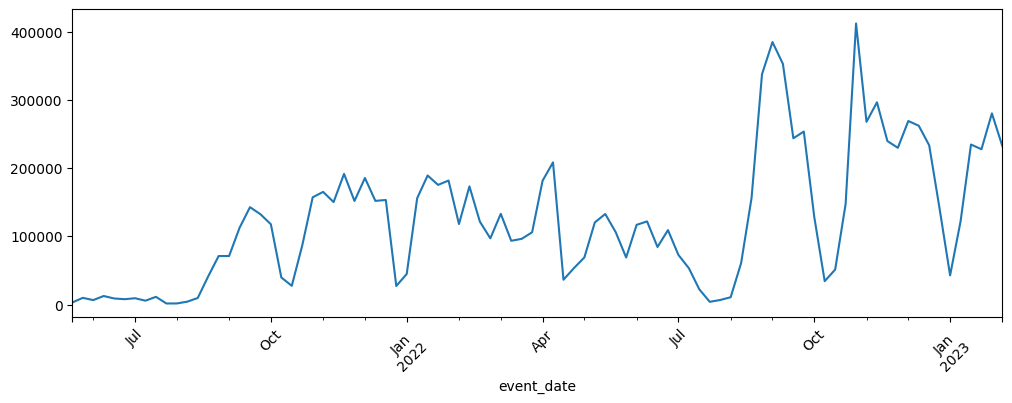

In [31]:
# Count total events per calendar week
weekly_events = events_clean.groupby(events_clean['event_date'].dt.to_period('W')).size()

# Drop the last week only if the dataset stops before that weekly period ends
last_week = weekly_events.index[-1]
if events_clean['event_date'].max() < last_week.end_time:
    weekly_events = weekly_events.iloc[:-1]

# Plot weekly event volume
weekly_events.plot(figsize=(12, 4))
plt.xticks(rotation=45)
plt.show()

In [32]:
# Quick sanity check of the engineered user-level feature table
print(user_features.shape)
print(user_features.head())

# Top 20 columns with missing values
print(user_features.isna().sum().sort_values(ascending=False).head(20))

# Share of users with events, transactions, and valid response-time info
print(user_features[['has_events', 'has_transactions', 'has_response_time']].mean())

(30929, 61)
   user_id   gender   canton          class_level  study class_id  n_events  \
0   387604  Unknown  Unknown              Unknown  False  Unknown    5087.0   
1   387605  Unknown  Unknown              Unknown  False  Unknown    3604.0   
2   387608  Unknown  Unknown              Unknown   True    9Q2M7    2359.0   
3   387613  Unknown  Unknown              Unknown  False  Unknown     213.0   
4   387615     MALE       SG  Gymnasium - 3. Jahr  False  Unknown     535.0   

   n_active_days  n_active_weeks             first_event  ...  \
0          100.0            54.0 2021-05-22 05:12:11.416  ...   
1           54.0            33.0 2021-05-27 06:46:53.301  ...   
2           87.0            47.0 2021-09-05 08:29:42.198  ...   
3            5.0             4.0 2021-07-28 07:55:26.135  ...   
4           12.0             9.0 2021-08-28 13:14:30.684  ...   

  avg_response_time  median_response_time  n_challenges  has_events  \
0         53.863150               18.2290          

In [33]:
print(dropout_dataset.shape)
print(dropout_dataset['dropout'].value_counts())
print(dropout_dataset['dropout'].value_counts(normalize=True).round(3))
print(dropout_dataset.head())

(22470, 28)
dropout
1    14577
0     7893
Name: count, dtype: int64
dropout
1    0.649
0    0.351
Name: proportion, dtype: float64
   user_id  total_events_0_2  total_transactions_0_2  total_clicks_0_2  \
0   387604               2.0                     2.0               0.0   
1   387605              12.0                     5.0               7.0   
2   387608             101.0                    34.0              35.0   
3   387613              11.0                     2.0               3.0   
4   387615             348.0                    37.0              76.0   

   total_views_0_2  total_sessions_0_2  total_topics_event_0_2  \
0              2.0                 0.0                     0.0   
1              5.0                 2.0                     2.0   
2             66.0                 2.0                     1.0   
3              8.0                 1.0                     1.0   
4            272.0                 2.0                     1.0   

   total_topics_transaction

### Alternative definition of dropout :

In [34]:
def overlaps_summer(row):
        if pd.isna(row["gap_start"]) or pd.isna(row["gap_end"]):
            return False

        start = row["gap_start"]
        end = row["gap_end"]

        # iterate over years spanned by the gap
        for year in range(start.year, end.year + 1):
            july_start = pd.Timestamp(year=year, month=7, day=1)
            aug_end = pd.Timestamp(year=year, month=8, day=31)

            # overlap condition
            if not (end < july_start or start > aug_end):
                return True

        return False

def compute_dropout(events_week, users_features):

    df = events_week.merge(
        users_features[["user_id", "first_event"]],
        on="user_id",
        how="left"
    )
    # compute week start date
    df["week_start"] = df["first_event"] + pd.to_timedelta(df["relative_week"] * 7, unit="D")

    # 1. ensure ordering
    df = df.sort_values(["user_id", "relative_week"]).copy()

    # 2. gap between weeks
    df["week_diff"] = df.groupby("user_id")["relative_week"].diff()

    df["prev_week_start"] = df.groupby("user_id")["week_start"].shift(1)

    df["gap_start"] = df["prev_week_start"] + pd.Timedelta(days=7)
    df["gap_end"] = df["week_start"] - pd.Timedelta(days=7)

    df["overlaps_summer"] = df.apply(overlaps_summer, axis=1)

    # 3. condition de dropout
    df["is_dropout_point"] = (
        (df["week_diff"] > 4) &            # >= 4 weeks gap
        (~df["overlaps_summer"])           # NOT during summer
    )
    # shift dropout to previous week (within each user)
    df["is_dropout_point"] = df.groupby("user_id")["is_dropout_point"].shift(-1).fillna(False)

    today = pd.Timestamp.today()

    # identify last week per user
    df["is_last_week"] = df.groupby("user_id")["relative_week"].transform("max") == df["relative_week"]

    # compute how old the last week is
    df["weeks_since"] = (today - df["week_start"]).dt.days / 7

    # apply rule only on last week
    df.loc[df["is_last_week"], "is_dropout_point"] = df.loc[df["is_last_week"], "weeks_since"] > 4

    # 3. récupérer le premier dropout par user
    dropout_df = df[df["is_dropout_point"]].copy()
    dropout_df["dropout_week"] = dropout_df["relative_week"].shift(1)

    first_dropout = (
        dropout_df.groupby("user_id")
        .first()[["dropout_week"]]
        .reset_index()
    )
    first_dropout["dropout_indicator"] = 1

    # 7. users sans dropout → dernière semaine
    last_weeks = (
        df.groupby("user_id")["relative_week"]
        .max()
        .reset_index()
        .rename(columns={"relative_week": "dropout_week"})
    )
    last_weeks["dropout_indicator"] = 0

    # 8. merge final
    result = last_weeks.merge(first_dropout, on="user_id", how="left", suffixes=("", "_drop"))

    # si dropout existe → overwrite
    result["dropout_indicator"] = result["dropout_indicator_drop"].fillna(result["dropout_indicator"])
    result["dropout_week"] = result["dropout_week_drop"].fillna(result["dropout_week"])

    # cleanup
    result = result[["user_id", "dropout_indicator", "dropout_week"]]

    return result, df

In [35]:
df_dropout, week_dropout_df = compute_dropout(user_week_features, user_features)

In [36]:
#week_dropout_df.loc[week_dropout_df["user_id"]==387615, ["user_id", "relative_week", "n_events", "cum_events", "cum_ratio", "week_diff", "is_dropout_point", "week_start"]]

In [37]:
df_dropout.head(5)

,user_id,dropout_indicator,dropout_week
0,387604,1,70
1,387605,1,87
2,387608,1,74
3,387613,1,72
4,387615,1,7


## LSTM Model

In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [39]:
def build_full_timeline(df):
    users = df["user_id"].unique()
    full_data = []

    for user in users:
        user_df = df[df["user_id"] == user]
        max_week = user_df["relative_week"].max()

        full_weeks = pd.DataFrame({
            "user_id": user,
            "relative_week": np.arange(0, max_week + 1)
        })

        merged = full_weeks.merge(
            user_df,
            on=["user_id", "relative_week"],
            how="left"
        )

        full_data.append(merged)

    return pd.concat(full_data, ignore_index=True)

df_full = build_full_timeline(user_week_features)

In [40]:
feature_cols = [
    # --- Baseline (14) ---
    'n_events', 'n_active_days', 'mean_hour',
    'n_click_events', 'n_view_events', 'n_sessions',
    'n_topics_event', 'n_transactions',
    'correct_rate', 'partial_rate', 'mean_evaluation_score',
    'avg_response_time', 'n_topics_transaction', 'n_documents',
    # Derived overall engagement score
    'activity_score',
    # --- Additional (8 features) ---
    # std twins
    'std_hour', 'std_evaluation_score', 'std_response_time',
    # session shape
    'session_duration_mean', 'session_duration_std',
    'time_between_sessions_mean',
    # engagement ratios
    'retry_ratio', 'review_rate',
]

df_full[feature_cols] = df_full[feature_cols].fillna(0)

In [41]:
def overlaps_summer_period(start, end):
    if pd.isna(start) or pd.isna(end):
        return False

    for year in range(start.year, end.year + 1):
        july_start = pd.Timestamp(year=year, month=7, day=1)
        aug_end = pd.Timestamp(year=year, month=8, day=31)

        if not (end < july_start or start > aug_end):
            return True

    return False


def compute_dropout_full_timeline(df, users_features, horizon=4):
    df = df.merge(
        users_features[["user_id", "first_event"]],
        on="user_id",
        how="left"
    )

    # compute week_start
    df["week_start"] = df["first_event"] + pd.to_timedelta(df["relative_week"] * 7, unit="D")

    df = df.sort_values(["user_id", "relative_week"]).copy()

    # activity indicator
    df["is_active"] = (df["n_events"] > 0).astype(int)

    labels = []

    for user_id, user_df in df.groupby("user_id"):
        user_df = user_df.sort_values("relative_week")
        activity = user_df["is_active"].values
        weeks = user_df["week_start"].values
        n = len(user_df)

        user_labels = np.full(n, np.nan)

        for i in range(n):
            # need full horizon
            if i + horizon < n:
                future_activity = activity[i+1:i+1+horizon]

                if np.all(future_activity == 0):
                    gap_start = weeks[i] + np.timedelta64(7, 'D')
                    gap_end = weeks[i] + np.timedelta64(7*horizon, 'D')

                    if not overlaps_summer_period(pd.Timestamp(gap_start), pd.Timestamp(gap_end)):
                        user_labels[i] = 1
                    else:
                        user_labels[i] = 0
                else:
                    user_labels[i] = 0
            else:
                user_labels[i] = np.nan  # cannot determine

        labels.extend(user_labels)

    df["is_dropout_point"] = labels
    return df

df_full = compute_dropout_full_timeline(df_full, user_features)

In [42]:
# Step 1: get the starting week (relative_week = 0) for each user
start_dates = (
    week_dropout_df[week_dropout_df["relative_week"] == 0]
    [["user_id", "week_start"]]
    .rename(columns={"week_start": "start_date"})
)

# Step 2: merge with df_full
df_full = df_full.merge(start_dates, on="user_id", how="left")

# Step 3: reconstruct the actual date for each row
df_full["date"] = df_full["start_date"] + pd.to_timedelta(df_full["relative_week"] * 7, unit="D")

# Step 4: extract year and day of year
df_full["year"] = df_full["date"].dt.year
df_full["day"] = df_full["date"].dt.dayofyear

# Optional: drop helper columns if you don't need them
df_full = df_full.drop(columns=["start_date", "date"])

feature_cols.append("year")
feature_cols.append("day")

In [43]:
df_full.head(30)

,user_id,relative_week,n_events,n_active_days,mean_hour,std_hour,n_click_events,n_view_events,n_sessions,n_topics_event,...,session_duration_std,time_between_sessions_mean,review_rate,activity_score,first_event,week_start,is_active,is_dropout_point,year,day
0,387604,0,2.0,2.0,9.000000,5.656854,0.0,2.0,0.0,0.0,...,0.000000,0.000000,0.000000,6.0,2021-05-22 05:12:11.416,2021-05-22 05:12:11.416,1,0.0,2021,142
1,387604,1,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,2021-05-22 05:12:11.416,2021-05-29 05:12:11.416,0,0.0,2021,149
2,387604,2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,2021-05-22 05:12:11.416,2021-06-05 05:12:11.416,0,0.0,2021,156
3,387604,3,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,2021-05-22 05:12:11.416,2021-06-12 05:12:11.416,0,0.0,2021,163
4,387604,4,7.0,1.0,8.000000,0.000000,4.0,3.0,1.0,1.0,...,0.000000,0.000000,0.000000,14.0,2021-05-22 05:12:11.416,2021-06-19 05:12:11.416,1,0.0,2021,170
5,387604,5,25.0,1.0,8.800000,0.408248,12.0,13.0,2.0,2.0,...,0.000000,0.000000,0.000000,59.0,2021-05-22 05:12:11.416,2021-06-26 05:12:11.416,1,0.0,2021,177
6,387604,6,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,2021-05-22 05:12:11.416,2021-07-03 05:12:11.416,0,0.0,2021,184
7,387604,7,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,2021-05-22 05:12:11.416,2021-07-10 05:12:11.416,0,0.0,2021,191
8,387604,8,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,2021-05-22 05:12:11.416,2021-07-17 05:12:11.416,0,0.0,2021,198
9,387604,9,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,2021-05-22 05:12:11.416,2021-07-24 05:12:11.416,0,0.0,2021,205


In [44]:
users = df_full["user_id"].unique()

# First split: train+val vs test
train_val_users, test_users = train_test_split(
    users, test_size=0.2, random_state=42
)

# Second split: train vs validation
train_users, val_users = train_test_split(
    train_val_users, test_size=0.2, random_state=42
)

train_df = df_full[df_full["user_id"].isin(train_users)].copy()
val_df   = df_full[df_full["user_id"].isin(val_users)].copy()
test_df  = df_full[df_full["user_id"].isin(test_users)].copy()

In [45]:
scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [46]:
SEQUENCE_LENGTH = 12

def create_sequences(df):
    sequences = []
    labels = []

    for user_id, user_df in df.groupby("user_id"):
        user_df = user_df.sort_values("relative_week")

        data = user_df[feature_cols].values
        target = user_df["is_dropout_point"].values

        for i in range(SEQUENCE_LENGTH, len(user_df)):
            if np.isnan(target[i]):
              continue
            X = data[i-SEQUENCE_LENGTH:i]
            y = float(target[i])

            sequences.append(X)
            labels.append(y)

    return np.array(sequences), np.array(labels)

X_train, y_train = create_sequences(train_df)
X_val, y_val     = create_sequences(val_df)
X_test, y_test   = create_sequences(test_df)

In [47]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SequenceDataset(X_train, y_train)
val_dataset = SequenceDataset(X_val, y_val)
test_dataset = SequenceDataset(X_test, y_test)



train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [48]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden_size=64, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = h_n[-1]
        out = self.fc(out)
        return out.squeeze(-1)

In [49]:
from sklearn.metrics import f1_score
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(input_size=len(feature_cols)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
patience = 5  # early stopping patience

best_f1 = 0
best_model_weights = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

threshold = 0.5  # can tune later

for epoch in range(EPOCHS):

    # ===== TRAINING =====
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch)

        preds = preds.reshape(-1).float()
        y_batch = y_batch.reshape(-1).float()

        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)

            preds = preds.reshape(-1)
            y_batch = y_batch.reshape(-1)

            loss = criterion(preds, y_batch.float())
            val_loss += loss.item()

            probs = torch.sigmoid(preds)
            preds_binary = (probs > threshold).float()

            all_preds.extend(preds_binary.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    val_f1 = f1_score(all_labels, all_preds)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    # ===== EARLY STOPPING ON F1 =====
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print("New best model!")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("⏹ Early stopping triggered")
        break

# Load best model at the end
model.load_state_dict(best_model_weights)

print(f"Best Validation F1: {best_f1:.4f}")

Epoch 1 | Train Loss: 970.1849 | Val Loss: 227.4613 | Val F1: 0.8039
New best model!
Epoch 2 | Train Loss: 909.9554 | Val Loss: 219.4798 | Val F1: 0.7905
Epoch 3 | Train Loss: 883.3193 | Val Loss: 219.0207 | Val F1: 0.7783
Epoch 4 | Train Loss: 854.3603 | Val Loss: 212.8097 | Val F1: 0.8243
New best model!
Epoch 5 | Train Loss: 836.2653 | Val Loss: 219.2688 | Val F1: 0.8081
Epoch 6 | Train Loss: 817.9203 | Val Loss: 209.7755 | Val F1: 0.8227
Epoch 7 | Train Loss: 804.5635 | Val Loss: 210.4376 | Val F1: 0.8269
New best model!
Epoch 8 | Train Loss: 790.4149 | Val Loss: 207.1469 | Val F1: 0.8206
Epoch 9 | Train Loss: 776.0463 | Val Loss: 212.0494 | Val F1: 0.8210
Epoch 10 | Train Loss: 764.3581 | Val Loss: 208.6105 | Val F1: 0.8311
New best model!
Epoch 11 | Train Loss: 755.9003 | Val Loss: 212.6787 | Val F1: 0.8230
Epoch 12 | Train Loss: 739.8844 | Val Loss: 211.4411 | Val F1: 0.8270
Epoch 13 | Train Loss: 729.6244 | Val Loss: 211.3722 | Val F1: 0.8304
Epoch 14 | Train Loss: 719.1435 | V

In [50]:
from sklearn.metrics import roc_auc_score

model.eval()
preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        preds.extend(outputs.cpu().numpy())
        targets.extend(y_batch.numpy())

roc = roc_auc_score(targets, preds)
print("ROC-AUC:", roc)

ROC-AUC: 0.8870900459838899


In [51]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import numpy as np

model.eval()
preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        probs = torch.sigmoid(outputs)

        preds.extend(probs.cpu().numpy())
        targets.extend(y_batch.numpy())

preds = np.array(preds)
targets = np.array(targets)

In [52]:
threshold = 0.5
pred_labels = (preds > threshold).astype(int)

print("F1:", f1_score(targets, pred_labels))
print("Precision:", precision_score(targets, pred_labels))
print("Recall:", recall_score(targets, pred_labels))

F1: 0.8290802198270353
Precision: 0.7599875034170344
Recall: 0.9119921270912413


In [53]:
best_f1 = 0
best_thresh = 0

for t in np.linspace(0.1, 0.9, 50):
    pred_labels = (preds > t).astype(int)
    f1 = f1_score(targets, pred_labels)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best F1:", best_f1)
print("Best threshold:", best_thresh)

Best F1: 0.8307977189992214
Best threshold: 0.4591836734693878


## Light GBM

In [ ]:
flat_cols = [f"t{t}_{c}" for t in range(SEQUENCE_LENGTH) for c in feature_cols]
X_train_flat = pd.DataFrame(X_train.reshape(len(X_train), -1), columns=flat_cols)
X_val_flat   = pd.DataFrame(X_val.reshape(len(X_val),   -1), columns=flat_cols)
X_test_flat  = pd.DataFrame(X_test.reshape(len(X_test),  -1), columns=flat_cols)

In [55]:
import lightgbm as lgb

import os # some problem with mac lightgbm
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"


model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight="balanced", 
    random_state=42,
    n_jobs=1,
    verbose=-1,
)

model_lgb.fit(
    X_train_flat, y_train,
    eval_set=[(X_val_flat, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=True)]
)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's auc: 0.897722	valid_0's binary_logloss: 0.374877


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [56]:
from sklearn.metrics import roc_auc_score

preds = model_lgb.predict_proba(X_test_flat)[:, 1]

roc = roc_auc_score(y_test, preds)
print("LightGBM ROC-AUC:", roc)

/Users/maksim/studies/dasf/CS-421-Project-learnavi/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM ROC-AUC: 0.8954692497494782


In [57]:
from sklearn.metrics import f1_score, precision_score, recall_score

threshold = 0.5
pred_labels = (preds > threshold).astype(int)

print("F1:", f1_score(y_test, pred_labels))
print("Precision:", precision_score(y_test, pred_labels))
print("Recall:", recall_score(y_test, pred_labels))

F1: 0.8349338960423754
Precision: 0.7723379675735967
Recall: 0.9085711607854163


In [58]:
import numpy as np

best_f1 = 0
best_thresh = 0

for t in np.linspace(0.1, 0.9, 50):
    pred_labels = (preds > t).astype(int)
    f1 = f1_score(y_test, pred_labels)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best F1:", best_f1)
print("Best threshold:", best_thresh)

Best F1: 0.8372781065088757
Best threshold: 0.4591836734693878


## Feature-set ablation (LightGBM, cumulative)

Mirrors the cumulative ablation in `stage_1.ipynb`, adapted to the per-week / flattened-sequence representation: each row trains a fresh LightGBM on a 12-week × *k*-feature flat input.

- **Baseline** — 15 weekly features.
- **+ Additional** — the 8 weekly features from `stage_1.md`
- **+ Demographics** — the static 66-column user metadata block (study, class_year, gender / canton / school one-hots), appended once per sample to the flat sequence.
- **+ Objective time** — `year` and `day` (calendar columns added to `feature_cols` in cell 58). Baseline + Objective-time (= 17 weekly features) is the set `preprocess.ipynb`'s LightGBM trains on, so this row is the apples-to-apples reproduction of the ~0.8954 ROC-AUC reported there.

In [59]:
GROUP_BASELINE_WEEKLY = [
    'n_events', 'n_active_days', 'mean_hour',
    'n_click_events', 'n_view_events', 'n_sessions',
    'n_topics_event', 'n_transactions',
    'correct_rate', 'partial_rate', 'mean_evaluation_score',
    'avg_response_time', 'n_topics_transaction', 'n_documents',
    'activity_score',
]
GROUP_ADDITIONAL_WEEKLY = [
    'std_hour', 'std_evaluation_score', 'std_response_time',
    'session_duration_mean', 'session_duration_std',
    'time_between_sessions_mean',
    'retry_ratio', 'review_rate',
]
# Objective-time / calendar columns added to feature_cols in cell 58.
GROUP_OBJECTIVE_TIME = ['year', 'day']
print(f'baseline weekly:    {len(GROUP_BASELINE_WEEKLY):2d} features')
print(f'additional weekly:  {len(GROUP_ADDITIONAL_WEEKLY):2d} features')
print(f'objective time:     {len(GROUP_OBJECTIVE_TIME):2d} features')

baseline weekly:    15 features
additional weekly:   8 features
objective time:      2 features


In [60]:
def _demographic_features(users_df):
    u = users_df[['user_id', 'gender', 'canton', 'class_level', 'study']].copy()
    u['gender']      = u['gender'].fillna('Unknown').astype(str)
    u['canton']      = u['canton'].fillna('Unknown').astype(str)
    u['class_level'] = u['class_level'].fillna('Unknown').astype(str)
    u['school_type'] = u['class_level'].str.split(' - ').str[0].fillna('Unknown')
    year = u['class_level'].str.extract(r'(\d+)\. Jahr')[0]
    u['class_year'] = pd.to_numeric(year, errors='coerce').fillna(0).astype(int)
    u['study'] = u['study'].astype(int)
    dummies = pd.get_dummies(
        u[['gender', 'canton', 'school_type']],
        prefix=['gender', 'canton', 'school'],
    ).astype(int)
    return pd.concat(
        [u[['user_id', 'study', 'class_year']].reset_index(drop=True),
         dummies.reset_index(drop=True)],
        axis=1,
    )

demographics_feat = _demographic_features(users_clean)
demo_cols = [c for c in demographics_feat.columns if c != 'user_id']
print(f'demographics_feat: {demographics_feat.shape}  ({len(demo_cols)} feature columns)')
demographics_feat.head()

demographics_feat: (30929, 67)  (66 feature columns)


,user_id,study,class_year,gender_FEMALE,gender_MALE,gender_Other,gender_Unknown,canton_AG,canton_AI,canton_AR,...,school_Maturität für Erwachsene,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere
0,387604,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,387605,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,387608,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,387613,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,387615,0,3,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [61]:
# Sequence-builder that also tracks user_id per sample, so we can join the static
# demographic block onto the flat-sequence rows.
def create_sequences_with_uid(df, cols, sequence_length=SEQUENCE_LENGTH):
    sequences, labels, uids = [], [], []
    for user_id, user_df in df.groupby('user_id'):
        user_df = user_df.sort_values('relative_week')
        data = user_df[cols].values
        target = user_df['is_dropout_point'].values
        for i in range(sequence_length, len(user_df)):
            if np.isnan(target[i]):
                continue
            sequences.append(data[i - sequence_length:i])
            labels.append(float(target[i]))
            uids.append(user_id)
    return np.array(sequences), np.array(labels), np.array(uids)

In [66]:
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
)

def run_lgbm_seq(weekly_cols, demo_df=None, label='run'):
    Xt, yt, ut = create_sequences_with_uid(train_df, weekly_cols)
    Xv, yv, uv = create_sequences_with_uid(val_df,   weekly_cols)
    Xs, ys, us = create_sequences_with_uid(test_df,  weekly_cols)

    flat_cols = [f"t{t}_{c}" for t in range(SEQUENCE_LENGTH) for c in weekly_cols]
    Xt_flat = pd.DataFrame(Xt.reshape(len(Xt), -1), columns=flat_cols)
    Xv_flat = pd.DataFrame(Xv.reshape(len(Xv), -1), columns=flat_cols)
    Xs_flat = pd.DataFrame(Xs.reshape(len(Xs), -1), columns=flat_cols)

    if demo_df is not None:
        cols_d = [c for c in demo_df.columns if c != 'user_id']
        def _attach(uids):
            return (
                pd.DataFrame({'user_id': uids})
                .merge(demo_df, on='user_id', how='left')[cols_d]
                .fillna(0)
                .reset_index(drop=True)
            )
        Xt_flat = pd.concat([Xt_flat.reset_index(drop=True), _attach(ut)], axis=1)
        Xv_flat = pd.concat([Xv_flat.reset_index(drop=True), _attach(uv)], axis=1)
        Xs_flat = pd.concat([Xs_flat.reset_index(drop=True), _attach(us)], axis=1)

    m = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=31,
        class_weight='balanced', random_state=42, n_jobs=1, verbose=-1,
    )
    m.fit(
        Xt_flat, yt,
        eval_set=[(Xv_flat, yv)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    val_pp  = m.predict_proba(Xv_flat)[:, 1]
    test_pp = m.predict_proba(Xs_flat)[:, 1]

    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.1, 0.9, 50):
        f1 = f1_score(yv, (val_pp > t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    test_yhat = (test_pp > best_t).astype(int)

    return {
        'set': label,
        'n_features_flat': Xt_flat.shape[1],
        'test_roc_auc':    roc_auc_score(ys, test_pp),
        'test_f1':         f1_score(ys, test_yhat),
        'test_precision':  precision_score(ys, test_yhat),
        'test_recall':     recall_score(ys, test_yhat),
    }

### Cumulative ablation results

Each row adds the named group on top of the previous row's feature set. `n_features_flat` = 12 (sequence_length) × *k* weekly features, plus the demographic block on the last row.

In [67]:
cumulative_specs = [('Baseline', list(GROUP_BASELINE_WEEKLY), None)]
_running = list(GROUP_BASELINE_WEEKLY)
_running = _running + list(GROUP_ADDITIONAL_WEEKLY)
cumulative_specs.append(('+ Additional', list(_running), None))
_running = _running + list(GROUP_OBJECTIVE_TIME)
cumulative_specs.append(('+ Objective time', list(_running), None))
cumulative_specs.append(('+ Demographics', list(_running), demographics_feat))


cum_results = []
for label, cols, demo in cumulative_specs:
    n_extra = 0 if demo is None else (demo.shape[1] - 1)
    print(f"running '{label}'  (weekly={len(cols)}, demo+={n_extra})...")
    cum_results.append(run_lgbm_seq(cols, demo_df=demo, label=label))

cum_df = pd.DataFrame(cum_results)
cum_df.style.format({
    'test_roc_auc': '{:.4f}', 'test_f1': '{:.4f}',
    'test_precision': '{:.4f}', 'test_recall': '{:.4f}',
})

running 'Baseline'  (weekly=15, demo+=0)...
running '+ Additional'  (weekly=23, demo+=0)...
running '+ Objective time'  (weekly=25, demo+=0)...
running '+ Demographics'  (weekly=25, demo+=66)...


,set,n_features_flat,test_roc_auc,test_f1,test_precision,test_recall
0,Baseline,180,0.6033,0.6792,0.5309,0.9425
1,+ Additional,276,0.6125,0.6821,0.5355,0.9394
2,+ Objective time,300,0.8955,0.8364,0.7661,0.9209
3,+ Demographics,366,0.9151,0.8472,0.7779,0.9299
